**DATA CLEANING AND EDA**

In [4]:
import pandas as pd

df = pd.read_csv('Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', encoding='latin-1')
print(df.shape)

(23179, 79)


In [5]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [6]:
df.columns = df.columns.str.strip()

In [7]:
print(df['Label'].value_counts())

Label
BENIGN    20111
DDoS       3067
Name: count, dtype: int64


In [8]:
df.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [9]:
print(df.isnull().sum().sum())

64


In [10]:
import numpy as np
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

21


In [11]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [12]:
df.dropna(inplace=True)
print(df.shape)

(23166, 79)


In [13]:
print(df.duplicated().sum())

289


In [14]:
df.drop_duplicates(inplace=True)
print(df.shape)

(22877, 79)


In [15]:
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [16]:
cols = ['Destination Port', 'Flow Duration',
        'Total Fwd Packets', 'Total Backward Packets',
        'Total Length of Fwd Packets', 'Flow Bytes/s',
        'Flow Packets/s', 'Packet Length Mean',
        'Packet Length Std', 'SYN Flag Count',
        'ACK Flag Count', 'Label']

df = df[cols]
print(df.shape)

(22877, 12)


In [17]:
df.columns = ['dest_port', 'flow_duration',
              'total_fwd_packets', 'total_bwd_packets',
              'total_fwd_length', 'flow_bytes_per_sec',
              'flow_packets_per_sec', 'packet_length_mean',
              'packet_length_std', 'syn_flag_count',
              'ack_flag_count', 'label']

print(df.columns.tolist())

['dest_port', 'flow_duration', 'total_fwd_packets', 'total_bwd_packets', 'total_fwd_length', 'flow_bytes_per_sec', 'flow_packets_per_sec', 'packet_length_mean', 'packet_length_std', 'syn_flag_count', 'ack_flag_count', 'label']


In [18]:
df.head(3)

,dest_port,flow_duration,total_fwd_packets,total_bwd_packets,total_fwd_length,flow_bytes_per_sec,flow_packets_per_sec,packet_length_mean,packet_length_std,syn_flag_count,ack_flag_count,label
0,54865,3,2,0,12,4.000000e+06,666666.66670,6.0,0.0,0.0,1.0,BENIGN
1,55054,109,1,1,6,1.100917e+05,18348.62385,6.0,0.0,0.0,1.0,BENIGN
2,55055,52,1,1,6,2.307692e+05,38461.53846,6.0,0.0,0.0,1.0,BENIGN


In [19]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('cyber_analytics.db')
print("Database Connected ")

Database Connected 


In [20]:
df.to_sql('network_logs', conn,
                if_exists='replace',
                index=False)
print("Data Loaded ")

Data Loaded 


In [21]:
result = pd.read_sql_query("SELECT label, COUNT(*) FROM network_logs GROUP BY label", conn)
print(result)

    label  COUNT(*)
0  BENIGN     19810
1    DDoS      3067


**SQL QUERIES**

In [22]:
query = """
SELECT label,
       COUNT(*) AS total_records,
       ROUND(COUNT(*) * 100.0 /
       (SELECT COUNT(*) FROM network_logs), 2) AS percentage
FROM network_logs
GROUP BY label
"""
result = pd.read_sql_query(query, conn)
print(result)

    label  total_records  percentage
0  BENIGN          19810       86.59
1    DDoS           3067       13.41


In [23]:
query = """
SELECT label,
       ROUND(AVG(flow_duration), 2)        AS avg_flow_duration,
       ROUND(AVG(flow_bytes_per_sec), 2)   AS avg_bytes_per_sec,
       ROUND(AVG(total_fwd_packets), 2)    AS avg_fwd_packets,
       ROUND(AVG(syn_flag_count), 2)       AS avg_syn_flags
FROM network_logs
GROUP BY label
"""
result = pd.read_sql_query(query, conn)
print(result)

    label  avg_flow_duration  avg_bytes_per_sec  avg_fwd_packets  \
0  BENIGN        10843368.64         2184953.76             7.27   
1    DDoS        12866335.74           72169.69             4.16   

   avg_syn_flags  
0           0.05  
1           0.00  


In [24]:
query = """
SELECT dest_port,
       COUNT(*) AS attack_count
FROM network_logs
WHERE label = 'DDoS'
GROUP BY dest_port
ORDER BY attack_count DESC
LIMIT 10
"""
result = pd.read_sql_query(query, conn)
print(result)

   dest_port  attack_count
0         80          3067


In [25]:
query = """
SELECT dest_port, flow_bytes_per_sec, syn_flag_count, label,
       CASE
           WHEN flow_bytes_per_sec > 1000000
                AND syn_flag_count > 0  THEN 'CRITICAL'
           WHEN flow_bytes_per_sec > 500000 THEN 'HIGH'
           WHEN flow_bytes_per_sec > 100000 THEN 'MEDIUM'
           ELSE                                  'LOW'
       END AS severity_level
FROM network_logs
WHERE label = 'DDoS'
ORDER BY flow_bytes_per_sec DESC
LIMIT 20
"""
result = pd.read_sql_query(query, conn)
print(result)

    dest_port  flow_bytes_per_sec  syn_flag_count label severity_level
0          80         9558751.027             0.0  DDoS           HIGH
1          80         8351040.919             0.0  DDoS           HIGH
2          80         7588388.780             0.0  DDoS           HIGH
3          80         7316352.201             0.0  DDoS           HIGH
4          80         7252493.766             0.0  DDoS           HIGH
5          80         7128063.725             0.0  DDoS           HIGH
6          80         3186250.342             0.0  DDoS           HIGH
7          80         3103788.687             0.0  DDoS           HIGH
8          80         3036563.071             0.0  DDoS           HIGH
9          80         3000000.000             0.0  DDoS           HIGH
10         80         2993563.337             0.0  DDoS           HIGH
11         80         2813891.578             0.0  DDoS           HIGH
12         80         2780353.728             0.0  DDoS           HIGH
13    

In [26]:
query = """
SELECT dest_port,
       COUNT(*) AS total_hits,
       SUM(CASE WHEN label='DDoS'   THEN 1 ELSE 0 END) AS ddos_count,
       SUM(CASE WHEN label='BENIGN' THEN 1 ELSE 0 END) AS benign_count,
       ROUND(SUM(CASE WHEN label='DDoS'
             THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS ddos_percentage
FROM network_logs
GROUP BY dest_port
HAVING ddos_percentage > 80
ORDER BY ddos_percentage DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

Empty DataFrame
Columns: [dest_port, total_hits, ddos_count, benign_count, ddos_percentage]
Index: []


In [27]:
query = """
SELECT dest_port, flow_bytes_per_sec, label,
       ROUND(AVG(flow_bytes_per_sec) OVER(), 2) AS global_avg,
       ROUND((flow_bytes_per_sec - AVG(flow_bytes_per_sec)
       OVER()) / MAX(flow_bytes_per_sec) OVER(), 4) AS z_score
FROM network_logs
ORDER BY z_score DESC
LIMIT 20
"""
result = pd.read_sql_query(query, conn)
print(result)

    dest_port  flow_bytes_per_sec   label  global_avg  z_score
0       21161        2.070000e+09  BENIGN  1901703.82   0.9991
1       13759        2.070000e+09  BENIGN  1901703.82   0.9991
2       17781        2.070000e+09  BENIGN  1901703.82   0.9991
3       38594        1.040000e+09  BENIGN  1901703.82   0.5015
4       39270        1.040000e+09  BENIGN  1901703.82   0.5015
5       33698        1.040000e+09  BENIGN  1901703.82   0.5015
6       23029        1.040000e+09  BENIGN  1901703.82   0.5015
7       23229        1.040000e+09  BENIGN  1901703.82   0.5015
8       24664        1.040000e+09  BENIGN  1901703.82   0.5015
9       37528        1.040000e+09  BENIGN  1901703.82   0.5015
10      49285        1.040000e+09  BENIGN  1901703.82   0.5015
11      40460        1.040000e+09  BENIGN  1901703.82   0.5015
12      22792        1.040000e+09  BENIGN  1901703.82   0.5015
13      42969        1.040000e+09  BENIGN  1901703.82   0.5015
14      34805        6.170000e+08  BENIGN  1901703.82  

In [28]:

traffic_overview = pd.read_sql_query(
    "SELECT label, COUNT(*) AS total FROM network_logs GROUP BY label", conn)

severity = pd.read_sql_query("""
SELECT label, dest_port, flow_bytes_per_sec,
       CASE
           WHEN flow_bytes_per_sec > 1000000 THEN 'CRITICAL'
           WHEN flow_bytes_per_sec > 500000  THEN 'HIGH'
           WHEN flow_bytes_per_sec > 100000  THEN 'MEDIUM'
           ELSE 'LOW'
       END AS severity_level
FROM network_logs""", conn)

traffic_overview.to_csv('traffic_overview.csv', index=False)
severity.to_csv('severity_data.csv', index=False)

print("Files Saved for Power BI ")

Files Saved for Power BI 


In [29]:

df.to_csv('cyber_final.csv', index=False)
traffic_overview.to_csv('traffic_overview.csv', index=False)
severity.to_csv('severity_data.csv', index=False)

print("All Files Saved ")

All Files Saved 


**MACHINE LEARNING**

In [30]:
from google.colab import files
files.download('cyber_final.csv')
files.download('traffic_overview.csv')
files.download('severity_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

print("Libraries Ready ")

Libraries Ready 


In [32]:
features = ['flow_duration', 'flow_bytes_per_sec',
            'flow_packets_per_sec', 'syn_flag_count',
            'packet_length_mean']

X = df[features].fillna(0)
print(X.shape)

(22877, 5)


In [33]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data Scaled ")

Data Scaled 


In [34]:
model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X_scaled)
print("Model Trained ")

Model Trained 


In [35]:
df['anomaly'] = model.predict(X_scaled)
df['anomaly'] = df['anomaly'].map({1: 'NORMAL', -1: 'ANOMALY'})

print(df['anomaly'].value_counts())

anomaly
NORMAL     21733
ANOMALY     1144
Name: count, dtype: int64


In [36]:
anomalies = df[df['anomaly'] == 'ANOMALY']
print(anomalies['label'].value_counts())

label
BENIGN    1114
DDoS        30
Name: count, dtype: int64


In [37]:
model = IsolationForest(contamination=0.1,
                        n_estimators=300,
                        random_state=42)
model.fit(X_scaled)
print("Model Retrained ")

Model Retrained 


In [38]:
df['anomaly'] = model.predict(X_scaled)
df['anomaly'] = df['anomaly'].map({1:'NORMAL', -1:'ANOMALY'})

anomalies = df[df['anomaly'] == 'ANOMALY']
print(anomalies['label'].value_counts())

label
BENIGN    2154
DDoS       134
Name: count, dtype: int64


In [39]:
df['anomaly_score'] = model.decision_function(X_scaled)
df['anomaly_score'] = df['anomaly_score'].round(4)
print(df[['label','anomaly','anomaly_score']].head(10))

    label  anomaly  anomaly_score
0  BENIGN  ANOMALY        -0.0514
1  BENIGN   NORMAL         0.1819
2  BENIGN   NORMAL         0.1630
3  BENIGN   NORMAL         0.1344
4  BENIGN  ANOMALY        -0.0514
5  BENIGN   NORMAL         0.1940
6  BENIGN  ANOMALY        -0.0282
7  BENIGN   NORMAL         0.1513
8  BENIGN  ANOMALY        -0.0282
9  BENIGN  ANOMALY        -0.1248


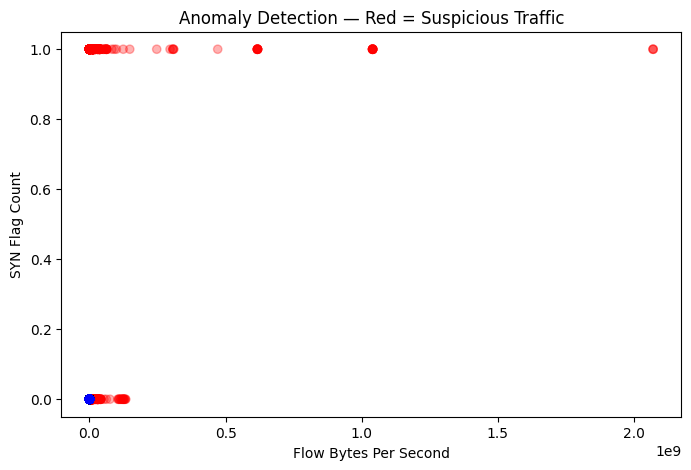

In [40]:
plt.figure(figsize=(8,5))
plt.scatter(df['flow_bytes_per_sec'],
            df['syn_flag_count'],
            c=df['anomaly'].map({'NORMAL':'blue', 'ANOMALY':'red'}),
            alpha=0.3)
plt.xlabel('Flow Bytes Per Second')
plt.ylabel('SYN Flag Count')
plt.title('Anomaly Detection — Red = Suspicious Traffic')
plt.show()

In [41]:
df.to_csv('anomaly_results.csv', index=False)
print(df.columns.tolist())
print(df.shape)

['dest_port', 'flow_duration', 'total_fwd_packets', 'total_bwd_packets', 'total_fwd_length', 'flow_bytes_per_sec', 'flow_packets_per_sec', 'packet_length_mean', 'packet_length_std', 'syn_flag_count', 'ack_flag_count', 'label', 'anomaly', 'anomaly_score']
(22877, 14)


In [42]:
from google.colab import files
files.download('anomaly_results.csv')
print("Downloaded ")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded 


In [43]:
print(df['label'].value_counts())

label
BENIGN    19810
DDoS       3067
Name: count, dtype: int64


In [44]:

benign_count = len(df[df['label'] == 'BENIGN'])
ddos_count   = len(df[df['label'] == 'DDoS'])

print(f"BENIGN rows: {benign_count}")
print(f"DDoS rows:   {ddos_count}")

sample_size = min(benign_count, ddos_count, 5000)
print(f"Sample size: {sample_size}")


benign_sample = df[df['label'] == 'BENIGN'].sample(sample_size, random_state=42)
ddos_sample   = df[df['label'] == 'DDoS'].sample(sample_size, random_state=42)
final_df = pd.concat([benign_sample, ddos_sample]).reset_index(drop=True)

print(final_df.shape)
print(final_df['label'].value_counts())

BENIGN rows: 19810
DDoS rows:   3067
Sample size: 3067
(6134, 14)
label
BENIGN    3067
DDoS      3067
Name: count, dtype: int64


In [45]:

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

features = ['flow_duration', 'flow_bytes_per_sec',
            'flow_packets_per_sec', 'syn_flag_count',
            'packet_length_mean']

X = final_df[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = IsolationForest(contamination=0.1,
                        n_estimators=300,
                        random_state=42)
model.fit(X_scaled)

final_df['anomaly'] = model.predict(X_scaled)
final_df['anomaly'] = final_df['anomaly'].map({1:'NORMAL', -1:'ANOMALY'})
final_df['anomaly_score'] = model.decision_function(X_scaled).round(4)


final_df['severity_level'] = final_df['flow_bytes_per_sec'].apply(
    lambda x: 'CRITICAL' if x > 1000000 else
              'HIGH'     if x > 500000  else
              'MEDIUM'   if x > 100000  else 'LOW')

print(final_df.shape)
print(final_df['label'].value_counts())
print(final_df['anomaly'].value_counts())
print(final_df['severity_level'].value_counts())

(6134, 15)
label
BENIGN    3067
DDoS      3067
Name: count, dtype: int64
anomaly
NORMAL     5520
ANOMALY     614
Name: count, dtype: int64
severity_level
LOW         4736
CRITICAL     594
MEDIUM       525
HIGH         279
Name: count, dtype: int64


In [47]:
final_df.to_csv('master_cyber_data.csv', index=False)

from google.colab import files
files.download('master_cyber_data.csv')
print("Downloaded ")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded 
